## Data Loading & Exploration

- Load the dataset and perform basic exploration.

- 7Tasks to include:

- Load dataset using Pandas

- Show first few rows (head())

- Check dataset shape

- Check for missing values

- Show basic statistics (describe())

- Any other u feel necessary

In [ ]:
import kagglehub
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.


In [ ]:
import pandas as pd
import os

# Assuming the dataset file is named 'diabetes.csv' within the downloaded path
dataset_file = os.path.join(path, 'diabetes.csv')

# Load the dataset into a pandas DataFrame
df = pd.read_csv(dataset_file)

# Display the head of the DataFrame
# Show first few rows (head())
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
## Check dataset shape
print(df.shape)

(768, 9)


In [ ]:
## Check for missing values
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
## Show basic statistics (describe())
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# Checking the columns name using (columns)
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


## Data Preprocessing

**Prepare the data for training.**

Steps:

- Separate features (X) and target (y)

- Perform Train/Test Split

**Example:**

- 80% Training

- 20% Testing

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('Outcome', axis=1)  # All columns except 'Outcome' are features
y = df['Outcome']  # 'Outcome' is the target variable

# Perform Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (614, 8)
X_test shape: (154, 8)
y_train shape: (614,)
y_test shape: (154,)


## Model Training

Train at least 2 different classification models from the list below.

- Choose any two or more:

- Logistic Regression

- Random Forest

- Support Vector Machine (SVM)

- Decision Tree

- K-Nearest Neighbors (KNN)

### Logistic Regression | Decision Tree | K-Nearest Neighbors

In [ ]:
# Importing LogisticRegression, DecisionTreeClassifier, KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

### Logistic Regression

In [ ]:
# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is a good choice for small datasets
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

### Decision Tree Classifier

In [ ]:
# Initialize and train the Decision Tree model
dec_tree_model = DecisionTreeClassifier(random_state=42)
dec_tree_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dec_tree = dec_tree_model.predict(X_test)

### K-Nearest Neighbors Classifier (KNN)

In [ ]:
# Initialize and train the KNN model (e.g., with n_neighbors=5)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test)

# Model Evaluation
***Evaluate each model using the following metrics:***

- Accuracy

- Precision

- Recall

- F1 Score

- ROC-AUC Score

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Evaluation for Logistic Regression ---
print("\n--- Logistic Regression Evaluation ---")
y_pred_log_reg = log_reg_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log_reg):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_log_reg):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_log_reg):.4f}")
roc_auc_log_reg = roc_auc_score(y_test, log_reg_model.predict_proba(X_test)[:, 1])
print(f"ROC-AUC Score: {roc_auc_log_reg:.4f}")

# --- Evaluation for Decision Tree ---
print("\n--- Decision Tree Evaluation ---")
y_pred_dec_tree = dec_tree_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_dec_tree):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dec_tree):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dec_tree):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_dec_tree):.4f}")
roc_auc_dec_tree = roc_auc_score(y_test, dec_tree_model.predict_proba(X_test)[:, 1])
print(f"ROC-AUC Score: {roc_auc_dec_tree:.4f}")

# --- Evaluation for K-Nearest Neighbors ---
print("\n--- K-Nearest Neighbors (KNN) Evaluation ---")
y_pred_knn = knn_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_knn):.4f}")
roc_auc_knn = roc_auc_score(y_test, knn_model.predict_proba(X_test)[:, 1])
print(f"ROC-AUC Score: {roc_auc_knn:.4f}")


--- Logistic Regression Evaluation ---
Accuracy: 0.7597
Precision: 0.6800
Recall: 0.6182
F1 Score: 0.6476
ROC-AUC Score: 0.8193

--- Decision Tree Evaluation ---
Accuracy: 0.7468
Precision: 0.6250
Recall: 0.7273
F1 Score: 0.6723
ROC-AUC Score: 0.7424

--- K-Nearest Neighbors (KNN) Evaluation ---
Accuracy: 0.6623
Precision: 0.5246
Recall: 0.5818
F1 Score: 0.5517
ROC-AUC Score: 0.7201


### ROC Curve Visualization:

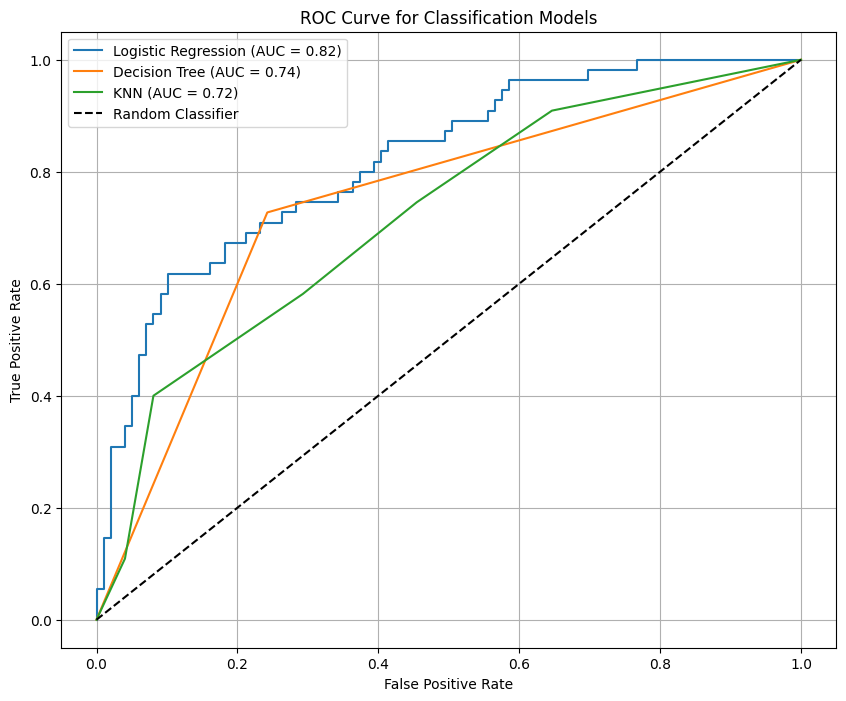

In [ ]:
plt.figure(figsize=(10, 8))

# Logistic Regression ROC Curve
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, log_reg_model.predict_proba(X_test)[:, 1])
plt.plot(fpr_log_reg, tpr_log_reg, label=f'Logistic Regression (AUC = {roc_auc_log_reg:.2f})')

# Decision Tree ROC Curve
fpr_dec_tree, tpr_dec_tree, _ = roc_curve(y_test, dec_tree_model.predict_proba(X_test)[:, 1])
plt.plot(fpr_dec_tree, tpr_dec_tree, label=f'Decision Tree (AUC = {roc_auc_dec_tree:.2f})')

# K-Nearest Neighbors ROC Curve
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_model.predict_proba(X_test)[:, 1])
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_knn:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Classification Models')
plt.legend()
plt.grid(True)
plt.show()

## Best Model Selection
- Compare performance of all models

- Choose the best performing model

Save the model using joblib

***Example:***

import joblib

joblib.dump(model, "diabetes_model.pkl")

In [ ]:
import joblib

# Store ROC-AUC scores for comparison
model_auc_scores = {
    'Logistic Regression': roc_auc_log_reg,
    'Decision Tree': roc_auc_dec_tree,
    'K-Nearest Neighbors': roc_auc_knn
}

# Find the best model based on ROC-AUC score
best_model_name = max(model_auc_scores, key=model_auc_scores.get)

if best_model_name == 'Logistic Regression':
    best_model = log_reg_model
elif best_model_name == 'Decision Tree':
    best_model = dec_tree_model
else:
    best_model = knn_model

print(f"The best performing model is: {best_model_name} with ROC-AUC score of {model_auc_scores[best_model_name]:.4f}")

# Save the best model
model_filename = f"{best_model_name.lower().replace(' ', '_')}_model.pkl"
joblib.dump(best_model, model_filename)
print(f"Best model saved as {model_filename}")

The best performing model is: Logistic Regression with ROC-AUC score of 0.8193
Best model saved as logistic_regression_model.pkl
